<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-burst-prediction/blob/main/MSc_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project

This notebook contains code for my MSc project. In particular, the code contains data pre-processing, feature engineering and modelling.

## Import Data and Packages

In [ ]:
# import packages required

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [ ]:
# mount Google Drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import data

assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding = "latin1")
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/burst_data.csv", encoding = "latin1")
soil = pd.read_csv("/content/drive/MyDrive/MSc project/soil-pipe-matched.csv", encoding = "latin1")

/tmp/ipykernel_872/3637998660.py:3: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding = "latin1")


# Data Cleaning

In this section data on assets, bursts and soil is cleaned, details follow below.

### Assets

It is desired to remove assets that are not of interest to the water networks maintenance planning team and duplicated assets.

In [ ]:
# removing assets that are not of interest to the team

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Abandoned"] # remove abondened assets

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Removed"] # remove removed assets

assets_cleaned = assets_cleaned.drop_duplicates(subset = ["Asset.ID"]) # remove duplicates


Some of the assets have missing values for diamater, age, material or surface. It is examined how severe the issue is by looking at the % of the total length of assets.

In [ ]:
# examine % of total length of assets that has missing diamater, age, material or surface code

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_DIAMETER'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_AGE'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_MATERIAL'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_SURFACE_CODE'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

0.0
0.0
0.0
8.067367176005064


Some missing values for the material could be imputed based on the information about the age of the asset.

<Axes: xlabel='ARM_AGE', ylabel='Count'>

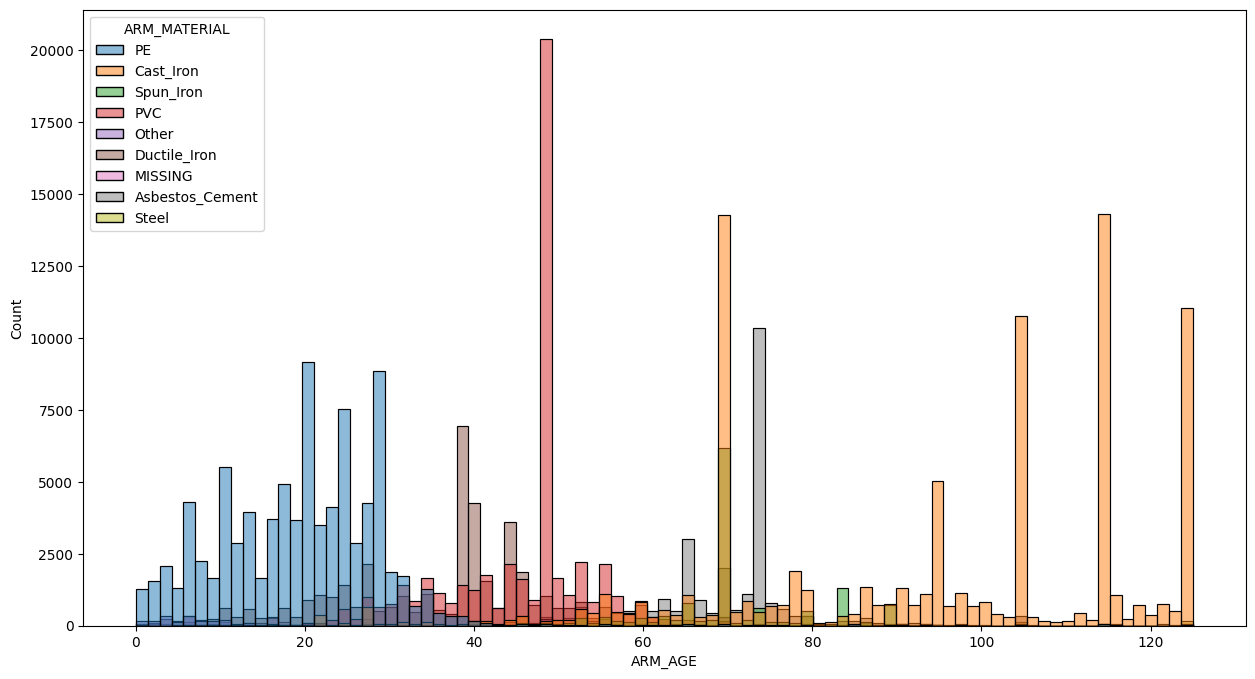

In [ ]:
# examine age profile of assets by material

plt.figure(figsize = [15, 8])
sns.histplot(data = assets_cleaned,
             x = "ARM_AGE",
             hue = "ARM_MATERIAL")

# comment: if an asset it 8 years or younger, then it can be assumed it is made of PE - use for subsitituing material

It is decided that records containing missing values for diamater are removed, since they onlymake up less than 1% of the total length of all assets.

Records containing missing values for age are also removed, since they only make 5% of the total length. It is impossible to impute the data based on some other characteristics.

Records that had missing material and were younger than 8 years old, were imputer with PE as material. The remaining records with misising material are removed, as it is impossible to safely assume what material they are based on age.

Assets with missing surface are removed from the data. It is impossible to impute using other characteristics.



In [ ]:
# missing values removal

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_AGE"])] # deletes records with missing age

assets_cleaned.loc[(assets_cleaned["ARM_MATERIAL"] == "MISSING") & (assets_cleaned["ARM_AGE"] <= 8.0), "ARM_MATERIAL"] = "PE" # imputes assets that have missing material and are 8 or less years with PE

assets_cleaned = assets_cleaned[(assets_cleaned["ARM_MATERIAL"] != "MISSING")] # removes remaining assets with missing material

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "Unknown"] # remove assets with unknown surface code (only 6 has unknown surface)

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "MISSING"] # remove assets with missing surface code (~52k has missing surface)



In [ ]:
# select columns and re-name columns

assets_cleaned = assets_cleaned[["Asset.ID",
                                 "ARM_MATERIAL",
                                 "ARM_DIAMETER",
                                 "ARM_LENGTH",
                                 "ARM_LINING",
                                 "ARM_SURFACE_CODE",
                                 "ARM_COMMISSIONED"
                                 ]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_LINING": "Lining",
                                                  "ARM_SURFACE_CODE": "Surface",
                                                  "ARM_COMMISSIONED": "Date_comm"}) # renaming columns


In [ ]:
# change type

assets_cleaned['Asset.ID'] = assets_cleaned['Asset.ID'].astype(int) # changing asset type from float to integer

assets_cleaned['Date_comm'] = pd.to_datetime(assets_cleaned['Date_comm'], errors = "coerce", dayfirst=True)


In [ ]:
# remove assets that don't have commissioned date in the right format

assets_cleaned = assets_cleaned[~(pd.isnull(assets_cleaned['Date_comm']))]

### Bursts

Bursts that occured at the same asset on the same day, or next day, are removed from the records. They are assumed to come from the same event, but work orders were raised multiple times.

In [ ]:
# bursts cleaning

bursts_cleaned = bursts.drop_duplicates(subset = ["Asset.ID", "Raised.Date"]) # delete duplicate bursts (same day at the same location) - most likely part of the same burst, but reported as two work orders

bursts_cleaned = bursts_cleaned[["Asset.ID", "Raised.Date"]] # only selecting relevant information

bursts_cleaned = bursts_cleaned[pd.notnull(bursts_cleaned['Asset.ID'])] # removing bursts without asset ID

bursts_cleaned['Asset.ID'] = bursts_cleaned['Asset.ID'].astype(int) # changing Asset ID from float to integer

In [ ]:
# only keep bursts if they occured more than 1 day between each other

bursts_cleaned = bursts_cleaned.sort_values(["Asset.ID", "Raised.Date"]) # sort bursts by date for each asset

bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transforms burst date to date format

kept_rows = [] # create an empty set to record temaining bursts



for asset_id, bursts in bursts_cleaned.groupby("Asset.ID"): # note: this is a special type of loop that loops through the created groups

    previous_date = None

    for _, row in bursts.iterrows():

        current_date = row["Raised.Date"]

        if previous_date is None:
            kept_rows.append(row)


        else:
            day_diff = (current_date - previous_date).days

            if day_diff > 1:
                kept_rows.append(row)
                previous_date = current_date

bursts_cleaned = pd.DataFrame(kept_rows)




### Soil

In [ ]:
# soil cleaning

soil_cleaned = soil[["Asset.ID", "Soil"]] # selecting only relevant information

soil_cleaned = soil_cleaned[pd.notnull(soil_cleaned["Soil"])] # removing assets with missing soil

# Data manipulation

In this section, data is manipulated to join assets, bursts and soil data together.

### Joining

Data on assets, bursts and soil needs to be joined together to form one dataset with attributes for modelling purposes.

In [ ]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = pd.merge(assets_bursts, soil_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Soil'])] # removing assets without soil

censored_data = assets_bursts_soil[~pd.notnull(assets_bursts_soil["Raised.Date"])] # keeping assets without bursts as censored data

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Raised.Date'])] # removing assets without bursts

Any assets that have censored data (have not had a burst yet) are saved in a separate file to later evaluate how the model performs on censored data.

In [ ]:
# save censored data

censored_data = censored_data.drop(columns = ["Raised.Date"]) # removed raised date, as won't be needed for further analysis

censored_data.to_csv("/content/drive/MyDrive/MSc project/censored_data.csv", encoding ='latin1', index=False)

### Transformations

The dataset is filtered to contain only the latest burst.

In [ ]:
# get index for latest two bursts for each asset

index = assets_bursts_soil.groupby("Asset.ID")["Raised.Date"].nlargest(2).reset_index(level = 0, drop = True).index

In [ ]:
# filter data to contain only latest two bursts

assets_bursts_soil_filtered = assets_bursts_soil.loc[index]

A column "Previous bursts" is added as attributes. This column corresponds to the number of previous failures.

In [ ]:
# Calculate previous fails for each asset

previous_bursts = assets_bursts_soil["Asset.ID"].value_counts() - 1

previous_bursts = previous_bursts.reset_index()


In [ ]:
# Add a new column

assets_bursts_soil_filtered = assets_bursts_soil_filtered.merge(previous_bursts, on = "Asset.ID", how = "left")
assets_bursts_soil_filtered = assets_bursts_soil_filtered.rename(columns={"count":"Previous bursts"}) # change column name

A "Time-to-break" column is added as a new attribute to the assets, bursts and soil data set. This column corresponds to the response attribute. Time-to-burst is calculated as time since install date or latest burst.

In [ ]:
# Change data type to date (necessary for calculating time difference)

assets_bursts_soil_filtered["Raised.Date"] = pd.to_datetime(assets_bursts_soil_filtered["Raised.Date"], dayfirst=True) # transofrms burst date to date format

assets_bursts_soil_filtered['Date_comm'] = pd.to_datetime(assets_bursts_soil_filtered["Date_comm"], errors = "coerce")

In [ ]:
# Sort records by raised date for each asset ID

assets_bursts_soil_filtered = assets_bursts_soil_filtered.sort_values(by = ["Asset.ID", "Raised.Date"])

In [ ]:
# Crate "Time-to-break" column

assets_bursts_soil_filtered.loc[assets_bursts_soil_filtered['Previous bursts'] == 0, "Time-to-break"] = \
  assets_bursts_soil_filtered['Raised.Date'] - assets_bursts_soil_filtered['Date_comm']

assets_bursts_soil_filtered.loc[assets_bursts_soil_filtered['Previous bursts'] > 0, "Time-to-break"] = \
  assets_bursts_soil_filtered.groupby("Asset.ID")["Raised.Date"].diff(1)

In [ ]:
# calculate "time-to-break"

# assets_bursts_soil_filtered["Time-to-break"] = assets_bursts_soil_filtered["Raised.Date"] - assets_bursts_soil_filtered['Date_comm']


In [ ]:
# Convert "Time-to-break" to days

assets_bursts_soil_filtered['Time-to-break'] = assets_bursts_soil_filtered['Time-to-break'].dt.days

In [ ]:
# remove assets that had fail on the same day as they were comissioned (likely an error)

assets_bursts_soil_filtered = assets_bursts_soil_filtered[~(assets_bursts_soil_filtered['Time-to-break'] == 0)]

A column "Age" is added. It equals 0 for assets that have not had any previous bursts, since time-to-failure since install is fitted. It equals to age at previous break, since time-to-failure since previous break is fitted.

In [ ]:
# Add "Age" column

assets_bursts_soil_filtered.loc[assets_bursts_soil_filtered["Previous bursts"] == 0, "Age"] = 0 # age at install

assets_bursts_soil_filtered.loc[assets_bursts_soil_filtered["Previous bursts"] > 0, "Age"] = \
  (assets_bursts_soil_filtered['Raised.Date'].shift(1) - assets_bursts_soil_filtered['Date_comm']).dt.days


In [ ]:
assets_bursts_soil_filtered = assets_bursts_soil_filtered[~(assets_bursts_soil_filtered['Age'] < 0)]

Save the final data set as attributes.

In [ ]:
# Only keep latest burst for each asset

index = assets_bursts_soil_filtered.groupby("Asset.ID")["Raised.Date"].nlargest(1).reset_index(level = 0, drop = True).index

In [ ]:
assets_bursts_soil_filtered = assets_bursts_soil_filtered.loc[index]

In [ ]:
# Remove assets that had burst data before commissioned date (happens due to data entry error)

assets_bursts_soil_filtered = assets_bursts_soil_filtered[assets_bursts_soil_filtered['Time-to-break'] > 0]

In [ ]:
# remove columns that won't be needed for further analysis

attributes = assets_bursts_soil.drop(columns = ["Date_comm", "Raised.Date"])

attributes = assets_bursts_soil_filtered

In [ ]:
# save attributes

attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)

# Feature Engineering

In this section, features are tested for correlation with the response attribute. This is done using visualisations and statistical tests.

In [ ]:
# import data (if starting code at this stage)

attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv")

### Numerical attributes

In this section, correlations are visually examined and statistically tested between numerical attributes.

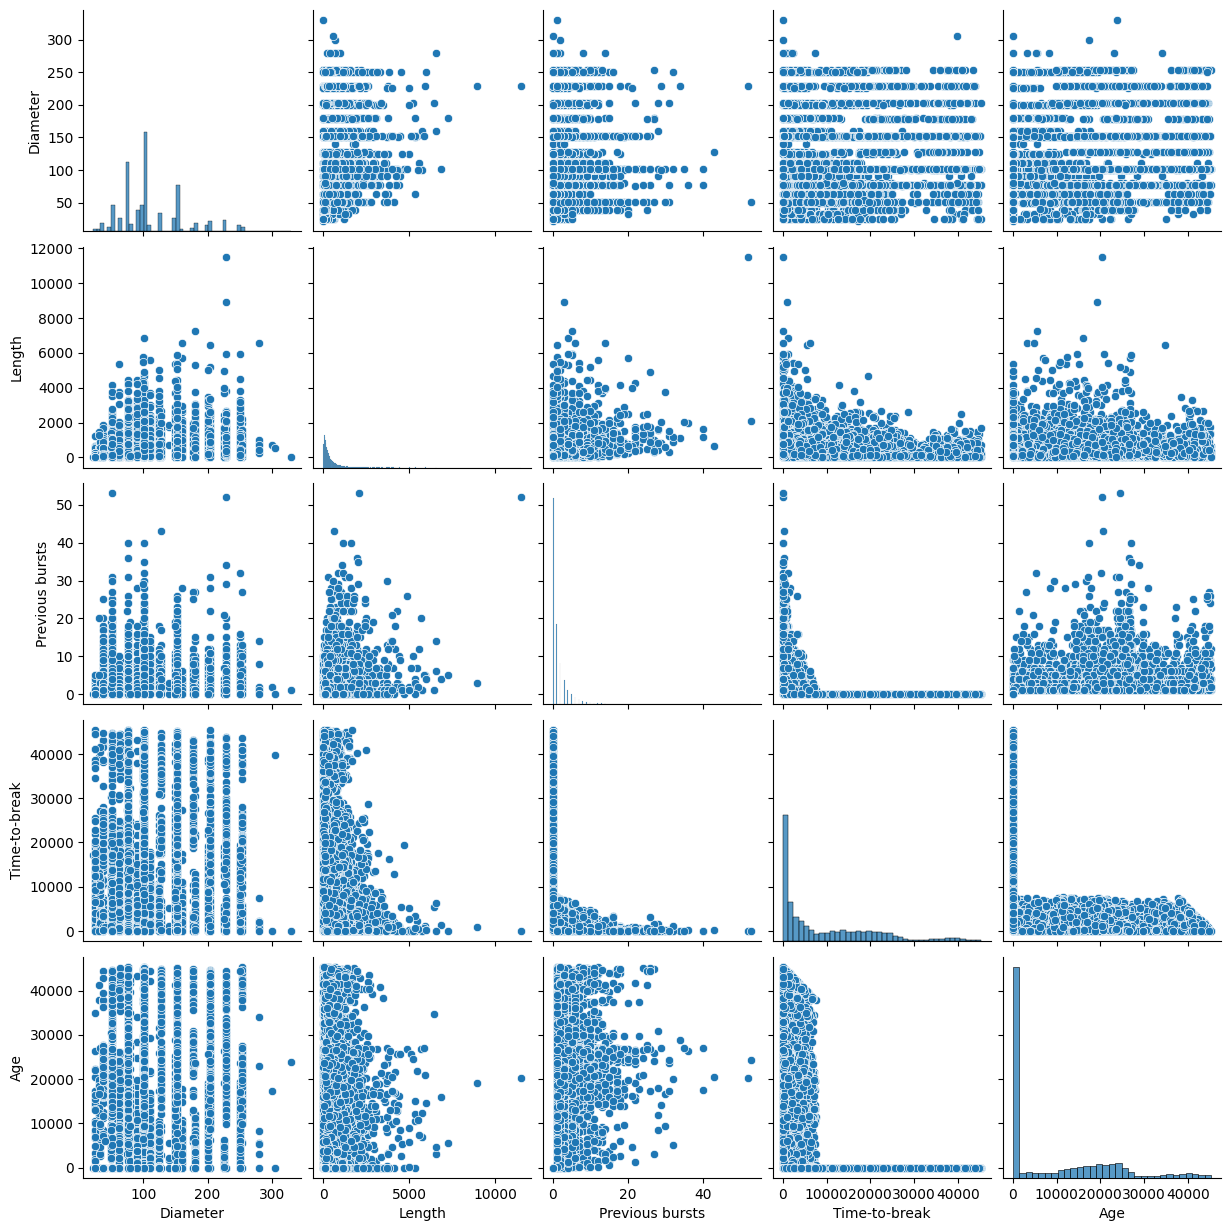

In [ ]:
# Examine correlations between numerical attributes

sns.pairplot(attributes.drop(columns = ["Asset.ID"]))

##### Length

Text(0, 0.5, 'Time-to-break (days)')

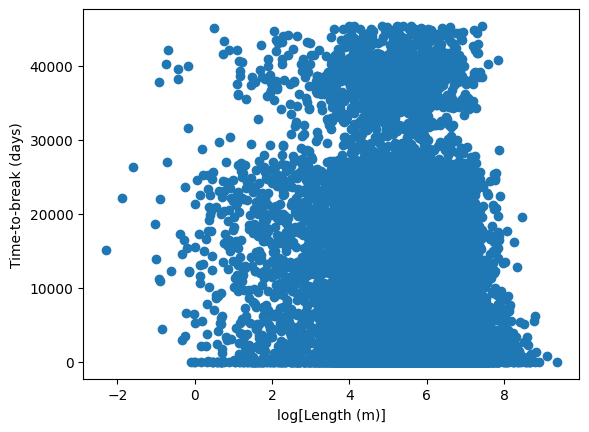

In [ ]:
# length vs time-to-break

plt.scatter(np.log(attributes['Length']), attributes["Time-to-break"]) # take log of length as highly skewed
plt.xlabel("log[Length (m)]")
plt.ylabel("Time-to-break (days)")

# comment: no strong relationship

In [ ]:
# length vs time-to-break

test = stats.spearmanr(a = attributes['Length'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.20827214113334253
p-value 4.628305449446994e-170


##### Diamater

Text(0, 0.5, 'Time-to-break (days)')

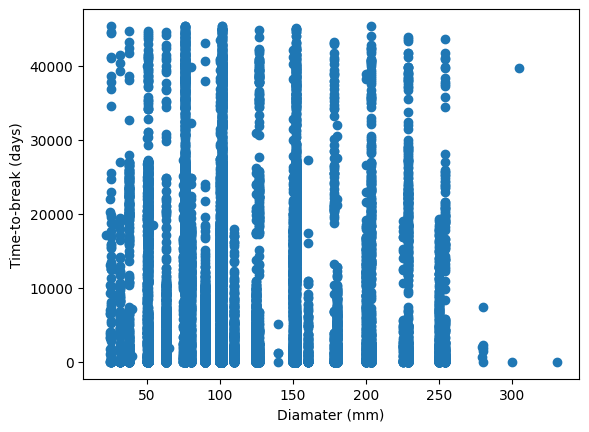

In [ ]:
# diamater vs time to break

plt.scatter(attributes['Diameter'], attributes["Time-to-break"])
plt.xlabel("Diamater (mm)")
plt.ylabel("Time-to-break (days)")

# comment: no obvious relationship

In [ ]:
# diamater vs time-to-break

test = stats.spearmanr(a = attributes['Diameter'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.013071612519651145
p-value 0.08442816288404505


##### Age

Text(0, 0.5, 'Time-to-break (days)')

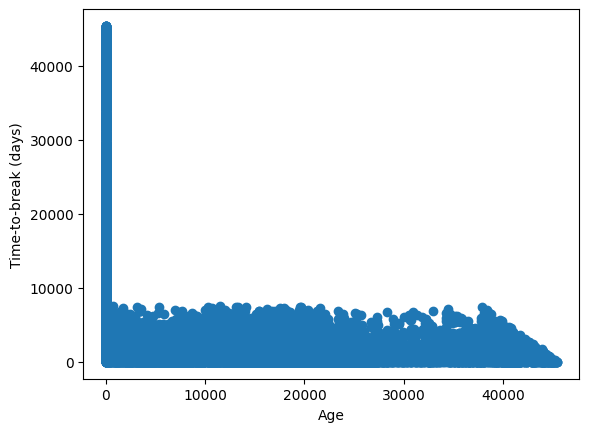

In [ ]:
# time to break vs age

plt.scatter(attributes["Age"], attributes["Time-to-break"])
plt.xlabel("Age")
plt.ylabel("Time-to-break (days)")


# comment: no relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Age'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.7699047868132136
p-value 0.0


##### Age (> 0 years)

Text(0, 0.5, 'Time-to-break (days)')

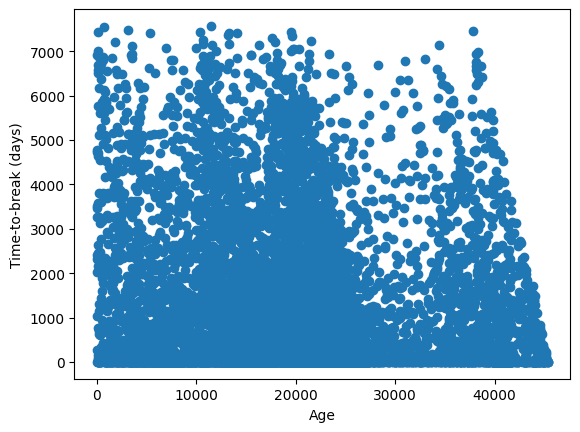

In [ ]:
# time to break vs age

plt.scatter(attributes[attributes["Age"] > 0]["Age"], attributes[attributes["Age"] > 0]["Time-to-break"])
plt.xlabel("Age")
plt.ylabel("Time-to-break (days)")


# comment: no relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes[attributes['Age'] > 0]['Age'], b = attributes[attributes["Age"] > 0]["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.09132865611537219
p-value 2.5674466683705202e-17


##### Previous bursts

Text(0, 0.5, 'Time-to-break (days)')

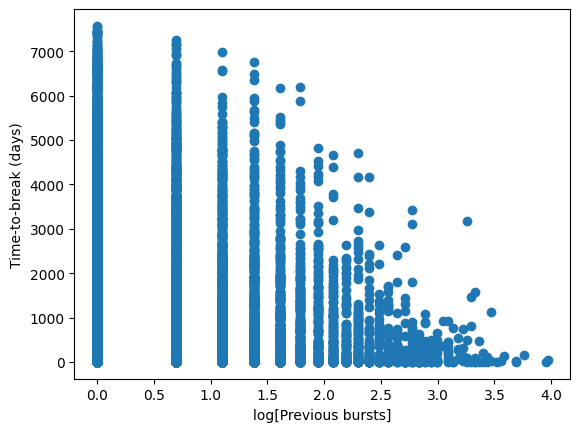

In [ ]:
# previous bursts vs time-to-break

plt.scatter(np.log(attributes['Previous bursts'][attributes['Previous bursts'] > 0]), attributes["Time-to-break"][attributes['Previous bursts'] > 0])
plt.xlabel("log[Previous bursts]")
plt.ylabel("Time-to-break (days)")

# comment: no strong relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Previous bursts'][attributes['Previous bursts'] > 0], b = attributes["Time-to-break"][attributes['Previous bursts'] > 0])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.19596441607919474
p-value 7.892113206976702e-75


### Categorical attributes

##### Material

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'log[Time-to-break]')

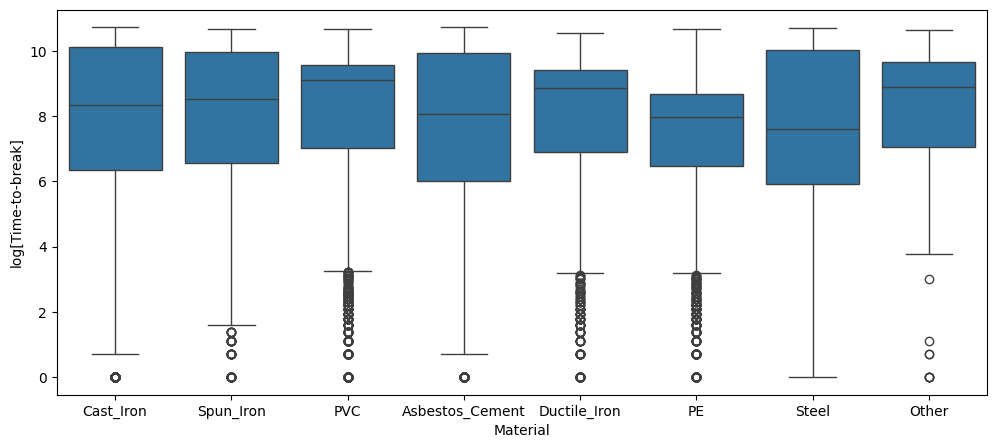

In [ ]:
# material vs time-to-break

plt.figure(figsize = (12, 5))
sns.boxplot( y = np.log(attributes["Time-to-break"]), x = attributes["Material"]) # adding a constant 10 to avoid infinity at time-to-break = 0
plt.ylabel("log[Time-to-break]")

# comment: some materials such as PE or Steel seem to have slightly lower time-to-break

In [ ]:
# splitting up material into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Material"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Material")


asbestos_cement = np.array(material_pivot["Asbestos_Cement"][pd.notnull(material_pivot["Asbestos_Cement"])])

spun_iron = np.array(material_pivot["Spun_Iron"][pd.notnull(material_pivot["Spun_Iron"])])

PVC = np.array(material_pivot["PVC"][pd.notnull(material_pivot["PVC"])])

cast_iron = np.array(material_pivot["Cast_Iron"][pd.notnull(material_pivot["Cast_Iron"])])

PE = np.array(material_pivot["PE"][pd.notnull(material_pivot["PE"])])

ductile_iron = np.array(material_pivot["Ductile_Iron"][pd.notnull(material_pivot["Ductile_Iron"])])

steel = np.array(material_pivot["Steel"][pd.notnull(material_pivot["Steel"])])

other = np.array(material_pivot["Other"][pd.notnull(material_pivot["Other"])])


KeyError: 'Asbestos_Cement'

In [ ]:
# one-way ANOVA for material

test = stats.f_oneway(np.log(asbestos_cement),
               np.log(spun_iron),
               np.log(PVC),
               np.log(cast_iron),
               np.log(PE),
               np.log(ductile_iron),
               np.log(steel),
               np.log(other))


print("statistic", np.exp(test.statistic))
print("p-value",  test.pvalue)


statistic nan
p-value nan


/tmp/ipykernel_872/750203135.py:7: RuntimeWarning: divide by zero encountered in log
  np.log(PE),
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:3974: RuntimeWarning: invalid value encountered in subtract
  alldata = alldata - offset
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:3982: RuntimeWarning: invalid value encountered in subtract
  smo_ss = _square_of_sums(sample - offset, axis=axis)
